In [1]:
import pandas as pd
housing = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv')

# import polars as pl
# housing = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv')

In [2]:
housing

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,1565930130,20141104T000000,4,3.25,3760,4675,2.0,0,0,3,...,2740,1020,2007,0,98038,47.3862,-122.048,3280,4033,429900.0
1,3279000420,20150115T000000,3,1.75,1460,7800,1.0,0,0,2,...,1040,420,1979,0,98023,47.3035,-122.382,1310,7865,233000.0
2,194000575,20141014T000000,4,1.00,1340,5800,1.5,0,2,3,...,1340,0,1914,0,98116,47.5658,-122.389,1900,5800,455000.0
3,2115510160,20141208T000000,3,1.75,1440,8050,1.0,0,0,3,...,1440,0,1985,0,98023,47.3187,-122.390,1790,7488,258950.0
4,7522500005,20140815T000000,2,1.50,1780,4750,1.0,0,0,4,...,1080,700,1947,0,98117,47.6859,-122.395,1690,5962,555000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5272200045,20141113T000000,3,1.50,1000,6914,1.0,0,0,3,...,1000,0,1947,0,98125,47.7144,-122.319,1000,6947,378000.0
19996,9578500790,20141111T000000,3,2.50,3087,5002,2.0,0,0,3,...,3087,0,2014,0,98023,47.2974,-122.349,2927,5183,399950.0
19997,7202350480,20140930T000000,3,2.50,2120,4780,2.0,0,0,3,...,2120,0,2004,0,98053,47.6810,-122.032,1690,2650,575000.0
19998,1723049033,20140620T000000,1,0.75,380,15000,1.0,0,0,3,...,380,0,1963,0,98168,47.4810,-122.323,1170,15000,245000.0


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt

# Load the dataset
url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv"
df = pd.read_csv(url)

# Drop columns that aren't useful features for a regression model
X = df.drop(columns=['id', 'date', 'price'])
y = df['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Initialize the XGBoost Regressor
model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

# Train the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

          Feature  Importance
8           grade    0.435733
2     sqft_living    0.190507
14            lat    0.074178
5      waterfront    0.072535
15           long    0.040368
6            view    0.039607
16  sqft_living15    0.030116
1       bathrooms    0.027327
11       yr_built    0.023194
13        zipcode    0.013511
9      sqft_above    0.012372
7       condition    0.007712
12   yr_renovated    0.007119
3        sqft_lot    0.006627
17     sqft_lot15    0.006438
0        bedrooms    0.004754
10  sqft_basement    0.004464
4          floors    0.003440


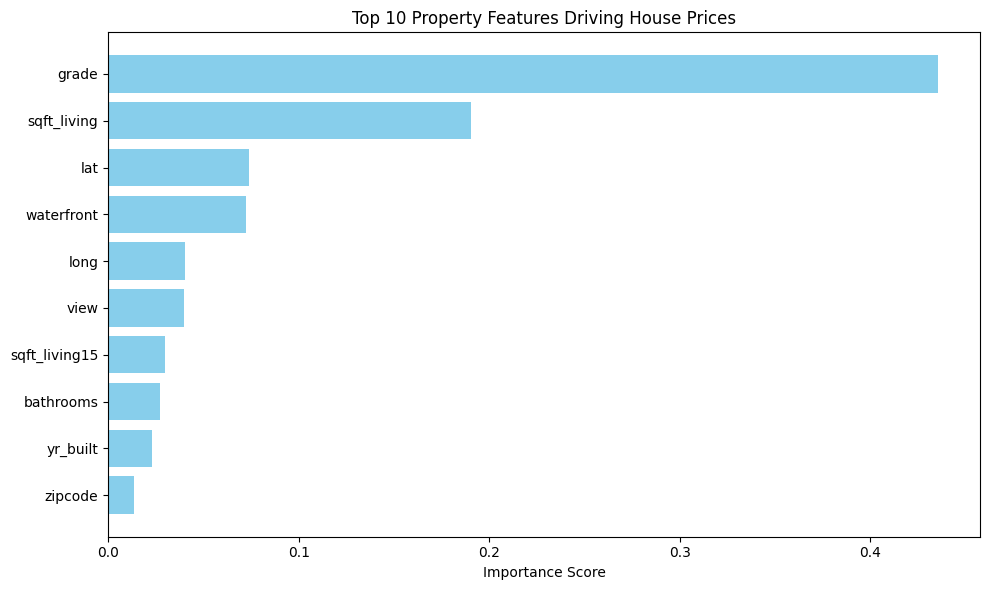

In [4]:
# Get feature importance weights
importances = model.feature_importances_

# Create a dataframe for easy viewing
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Plot the top features for William's report
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10][::-1], feature_importance_df['Importance'][:10][::-1], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Property Features Driving House Prices')
plt.tight_layout()
plt.show()

While traditional spreadsheets look at features in isolation (e.g., average price per square foot), our XGBoost model looks at interactions between features. For example, it doesn't just calculate the value of an extra bathroom; it calculates how much an extra bathroom is worth specifically inside a Grade 8 house vs. a Grade 6 house located in a high-value latitude.